1. Lesen Sie die Kapitel 5 (Punktoperationen - 5.2 Punktoperationen und Histogramme)
und Kapitel 6 (Filter 6.1 - 6.3 ) aus dem Buch ”Digitale Bildverarbeitung”.

In [79]:
import matplotlib.pyplot as plt
import skimage as sk
from matplotlib.pyplot import subplots

image_1 = sk.io.imread('bild01.jpg')
image_2 = sk.io.imread('bild02.jpg')

2. Implementieren Sie eine Funktion, die aus einem 8-Bit-Graustufenbild das zugeh¨orige
kumulative Histogramm berechnet.

• Prototyp: cumHisto = compute cumHisto(image, binSize)

• Das image ist ein 8-Bit-Grauwert Bild.

In [80]:
import numpy as np

# computes a histogram for an image
def compute_histo(image, bin_size=1):
    bins = 256 // bin_size
    hist = np.zeros(bins, dtype=int)

    for pixel in image.flatten():
        bin_idx = pixel // bin_size
        hist[bin_idx] += 1

    return hist

# computes a cumulative histogram from a histogram
def compute_cum_histo(hist):
    bins = len(hist)
    cum_hist = np.zeros(bins)

    cum_hist[0] = hist[0]
    for i in range(1, bins):
        cum_hist[i] = cum_hist[i-1] + hist[i]

    return cum_hist

# computes a normalized cumulative histogram from a histogram
def compute_normalized_cum_histogram(hist):
    bins = len(hist)
    normalized_hist = hist / hist.sum()
    norm_cum_hist = np.zeros(bins)

    norm_cum_hist[0] = normalized_hist[0]
    for i in range(1, bins):
        norm_cum_hist[i] = norm_cum_hist[i-1] + normalized_hist[i]

    return norm_cum_hist

# computes a cumulative histogram from an image -> this is an old function and can be replaced be newer ones on top (was used for a2)
def compute_cum_histo_og(image, bin_size=1):
    # 256 possible intensity values = 2^8

    # computes how many bins needed
    bins = 256 // bin_size

    # init histogram
    hist = np.zeros(bins, dtype=int)

    for pixel in image.flatten():
        bin_idx = pixel // bin_size
        hist[bin_idx] += 1

    cum_hist = np.zeros(bins, dtype=int)

    # first bin to start
    cum_hist[0] = hist[0]
    # now add each bin on top of previous to build cumulative histo
    for i in range(1, bins):
        cum_hist[i] = cum_hist[i-1] + hist[i]

    return cum_hist

Text(0.5, 0, 'intensity/value')

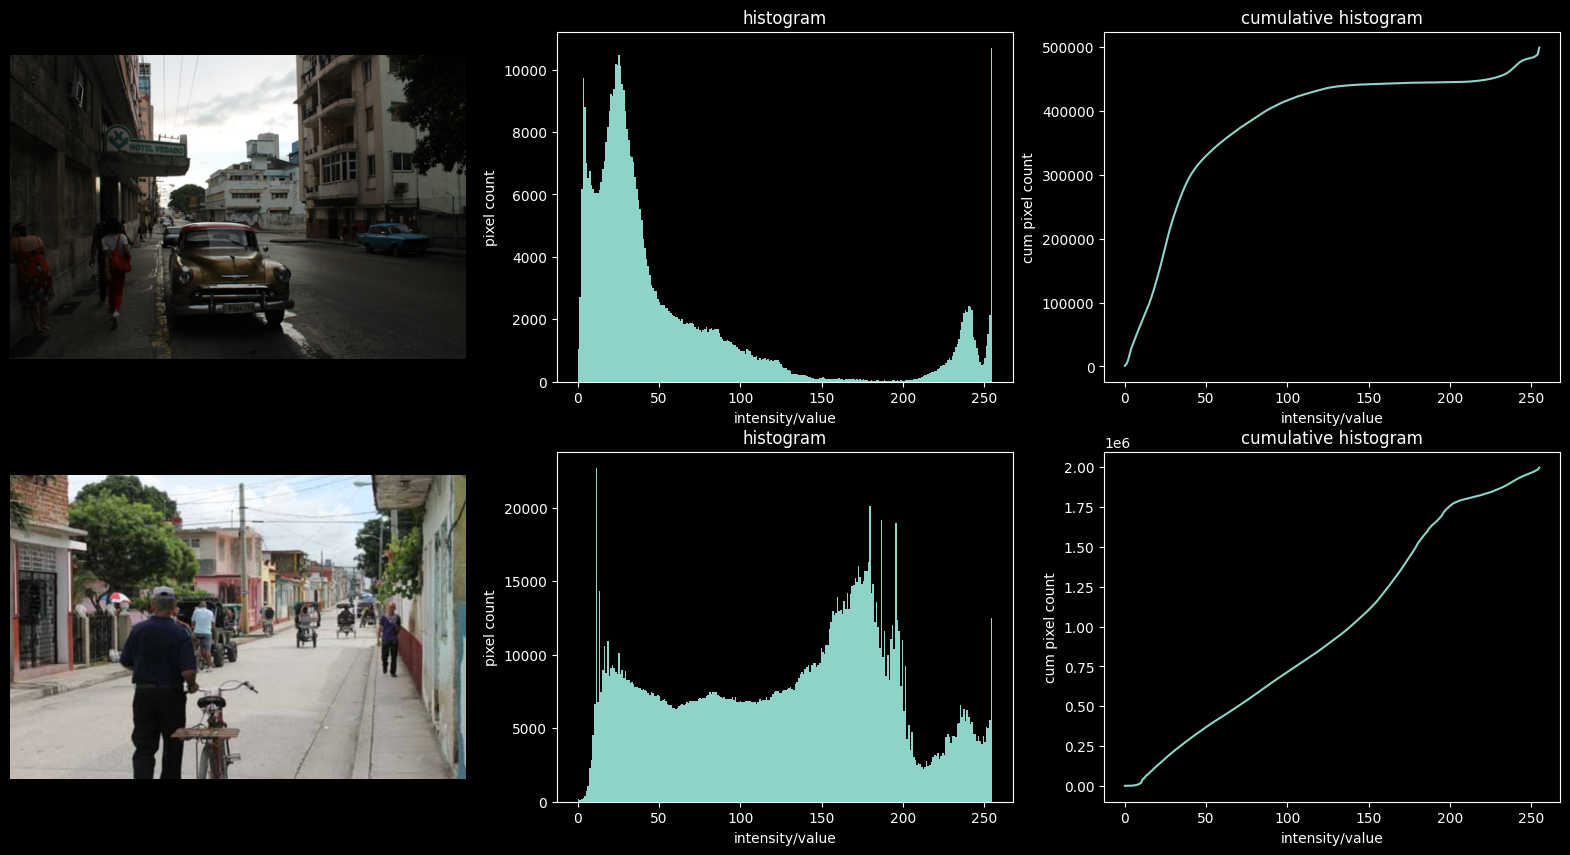

In [81]:
fig, axis = plt.subplots(2,3, figsize = (20,10))

# pic 1
axis[0,0].imshow(image_1)
axis[0,0].axis('off')

axis[0,1].hist(image_1.flatten(), bins=256)
axis[0,1].set_title('histogram')
axis[0,1].set_ylabel('pixel count')
axis[0,1].set_xlabel('intensity/value')

axis[0,2].plot(compute_cum_histo_og(image_1, 1))
axis[0,2].set_title('cumulative histogram')
axis[0,2].set_ylabel('cum pixel count')
axis[0,2].set_xlabel('intensity/value')


# pic 1
axis[1,0].imshow(image_2)
axis[1,0].axis('off')

axis[1,1].hist(image_2.flatten(), bins=256)
axis[1,1].set_title('histogram')
axis[1,1].set_ylabel('pixel count')
axis[1,1].set_xlabel('intensity/value')

axis[1,2].plot(compute_cum_histo_og(image_2, 1))
axis[1,2].set_title('cumulative histogram')
axis[1,2].set_ylabel('cum pixel count')
axis[1,2].set_xlabel('intensity/value')

3. Beantworten Sie folgende Fragen:

    a) Was ist eine homogene und was eine nicht-homogene Punktoperation?

    b) Was ist der Unterschied zwischen Punktoperationen und Filteroperationen?

a) <br>
homogene punktoperation: <br>
- jeder pixel wird nach der gleichen regel verändert, egal wo er im bild sitzt
- f() ist für jede bildposition immer gleich, sie hängt nur vom pixelwert ab
- `I′(u,v)←f(I(u,v))`
- z.B. jeden pixel um 50% heller machen

nicht-homogene punktoperation:
- die regel hängt davon ab, wo der pixel im bild sitzt
- koordinaten fließen in die funktion ein, also der gleiche pixelwert kann unterschiedliche ergebnisse je nach position liefern
- `I′(u,v)←g(I(u,v),u,v)`
- z.B. unregelmäßige beleuchtung ausgleichen

b) <br>
punktoperation:
- jedes pixel schaut nur den eigenen wert an und die bildgeometrie bleibt unverändert

filteroperation:
- jedes pixel schaut sich und seine nachbarn an, bildgeometrie bleibt auch unverändert, aber ermöglicht effekte die mit punktoperationen nicht möglich sind wie z.B. bilder glätten (einfache glättung = pixel durch durchschnitt der benachbarten pixel), bilder schärfen, kanten erkennen
- lineare filter -> pixelwerte innerhalb der filterregion in linearer Form, d.h. durch gewichtete summation verknüpfen
- nichtlineare filter -> kapitel 6.4 etc

=> Ergebnis nicht aus einem einzigen Ursprungspixel berechnet, sondern im Allgemeinen aus einer Menge von Pixeln des Originalbild

4. Implementieren Sie eine Funktion, die das Bild01 an das Bild02 mittels Histogram-
manpassung angleicht. Hierzu soll das kumulative Histogramm von Bild02 als Ref-
erenzverteilung dienen und das Bild01 so ver¨andert werden, dass sein kumulatives His-
togramm an die Referenzverteilung angeglichen wird. Schließlich soll das Referenzbild
(02) und das verarbeitete Bild (01) und deren kumulativen Histogramme angezeigt wer-
den.

    • Prototyp: LUT = match Histo(img histo, ref histo)

    • img histo: Histogramm des anzupassenden Bildes.

    • ref histo: Histogramm des Referenzbildes.

    • LUT: Die Lookup Tabelle, welche auf das anzupassende Bild angewendet, die
    Histogrammanpassung durchf¨uhrt.

Wieso m¨ussen die beiden Histogramme des Referenz- und des Orginalbildes normiert
sein? (Denken Sie an den Histogrammausgleich)

- Bild 1 und 2 können unterschiedlich viele pixel haben

In [82]:
print(f'bild1 hat {len(image_1.flatten())} pixel und bild 2 {len(image_2.flatten())} pixel')
print(f'die bilder haben eine differenz von {len(image_2.flatten()) - len(image_1.flatten())} pixel')

bild1 hat 499500 pixel und bild 2 1998000 pixel
die bilder haben eine differenz von 1498500 pixel


Dadurch sind die beiden Histogramme nicht vergleichbar. Um das problem zu lösen muss man die histogramme jetzt normieren, damit beide histogramme nur häufigkeiten von 0 bis 1 anzeigen.

In [83]:
def match_histo(img_histo, ref_histo):
    # histogramme normieren
    img_histo = img_histo / img_histo.sum()
    ref_histo = ref_histo / ref_histo.sum()

    # cum histo
    cum_img_histo = compute_cum_histo(img_histo)
    cum_ref_histo = compute_cum_histo(ref_histo)

    lut = np.zeros(256, dtype=int)
    for i in range(256):
        # find index j where cum_ref_histo[j], is closest to cum_ref_histo[i]
        diff = np.abs(cum_ref_histo - cum_img_histo[i])
        lut[i] = np.argmin(diff)

    return lut

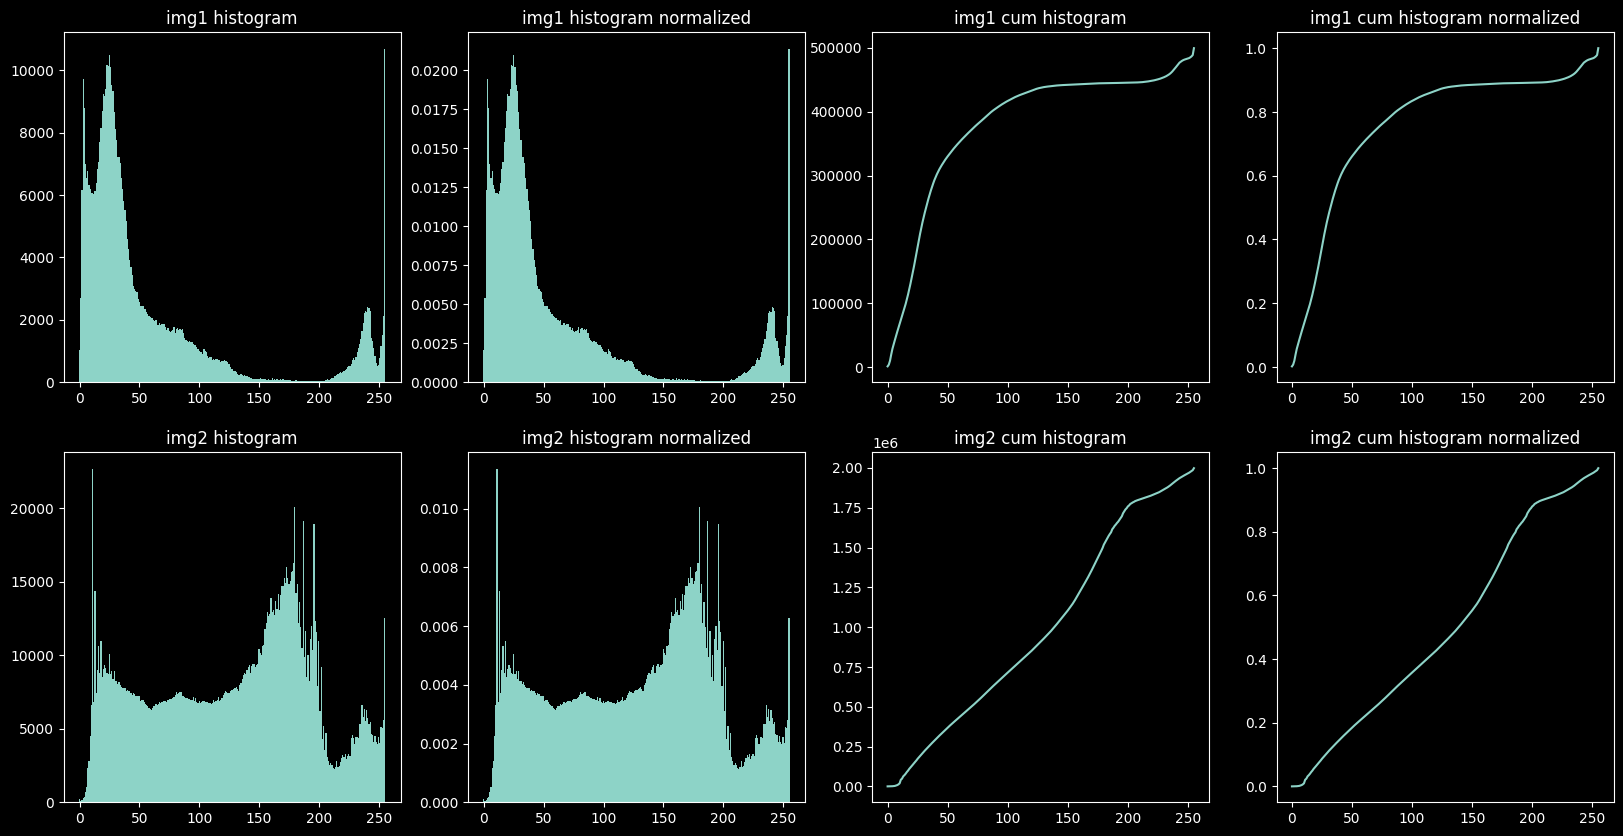

In [84]:
# histograms
img1_histo = compute_histo(image_1)
img2_histo = compute_histo(image_2)

# normalized histograms
img1_histo_norm = img1_histo / img1_histo.sum()
img2_histo_norm = img2_histo / img2_histo.sum()

# cumulative histograms
img1_cum_histo = compute_cum_histo(img1_histo)
img2_cum_histo = compute_cum_histo(img2_histo)

# normalized cumulative histograms
img1_norm_cum_histo = compute_cum_histo(img1_histo_norm)
img2_norm_cum_histo = compute_cum_histo(img2_histo_norm)

fig, axis = plt.subplots(2,4, figsize = (20,10))
#image 1
axis[0,0].set_title('img1 histogram')
axis[0,0].bar(range(len(img1_histo)), img1_histo, width=1.0)

axis[0,1].set_title('img1 histogram normalized')
axis[0,1].bar(range(len(img1_histo_norm)), img1_histo_norm, width=1.0)

axis[0,2].set_title('img1 cum histogram')
axis[0,2].plot(img1_cum_histo)

axis[0,3].set_title('img1 cum histogram normalized')
axis[0,3].plot(img1_norm_cum_histo)

# image 2
axis[1,0].set_title('img2 histogram')
axis[1,0].bar(range(len(img2_histo)), img2_histo, width=1.0)

axis[1,1].set_title('img2 histogram normalized')
axis[1,1].bar(range(len(img2_histo_norm)), img2_histo_norm, width=1.0)

axis[1,2].set_title('img2 cum histogram')
axis[1,2].plot(img2_cum_histo)

axis[1,3].set_title('img2 cum histogram normalized')
axis[1,3].plot(img2_norm_cum_histo)

Text(0.5, 0, 'intensity/value')

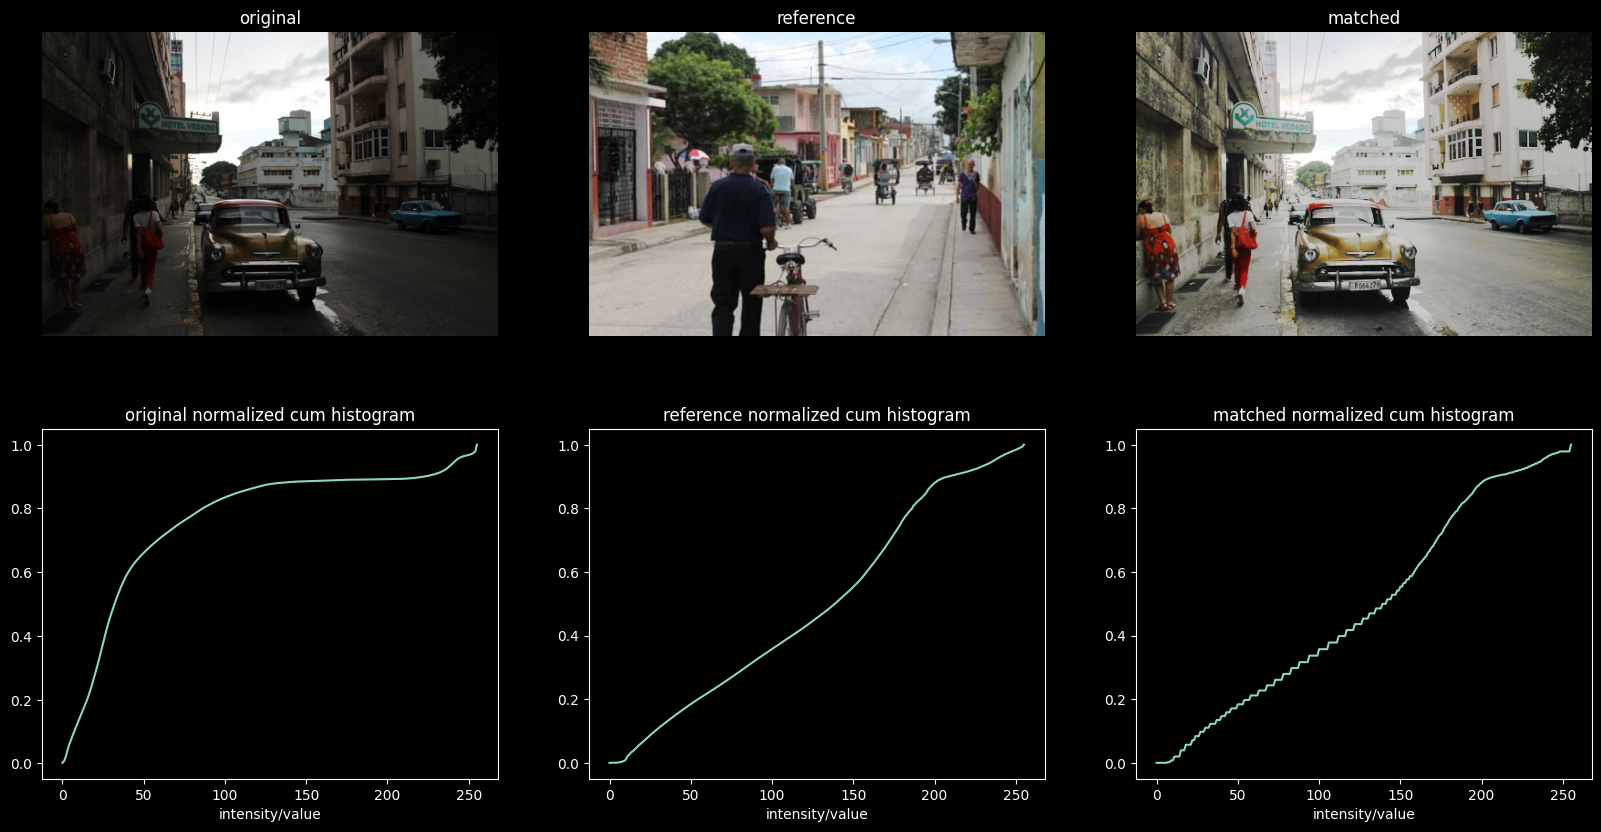

In [88]:
# create lut
lut = match_histo(img1_histo, img2_histo)

# apply lut to img 1
img1_matched = lut[image_1]

fig, axis = subplots(2, 3, figsize = (20,10))

axis[0,0].imshow(image_1, cmap='gray')
axis[0,0].set_title('original')
axis[0,0].axis('off')

axis[0,1].imshow(image_2, cmap='gray')
axis[0,1].set_title('reference')
axis[0,1].axis('off')

axis[0,2].imshow(img1_matched, cmap='gray')
axis[0,2].set_title('matched')
axis[0,2].axis('off')

axis[1,0].plot(compute_normalized_cum_histogram(compute_histo(image_1)))
axis[1,0].set_title('original normalized cum histogram')
axis[1,0].set_xlabel('intensity/value')

axis[1,1].plot(compute_normalized_cum_histogram(compute_histo(image_2)))
axis[1,1].set_title('reference normalized cum histogram')
axis[1,1].set_xlabel('intensity/value')


axis[1,2].plot(compute_normalized_cum_histogram(compute_histo(img1_matched)))
axis[1,2].set_title('matched normalized cum histogram')
axis[1,2].set_xlabel('intensity/value')


ohne normierung würde man histogramme vergleichen die bei 499.500 pixeln und 1.998.000 pixeln enden, das macht keinen sinn, also müssen die histogramme normalisiert werden, um sie zu vergleichen

die treppenform des matched histograms kann darauf zurückgeführt werden, dass jetzt meherere pixelwerte auf den neuen pixelwert abgebildet werden können, da nur 256 intensitätswerte zur verfügung stehen -> keine perfekte anpassung möglich